In [1]:
# Data visualization notebook that uses the `corr_matrix()` function to
# generate correlation matrices between atmospheric layers and the MASS
# instrument response.
# The MASS instrument has a broad triangular response function, producing
# expected overlap between adjacent layers but minimal correlation between
# layers separated by two or more steps.
# The notebook highlights and investigates cases of unexpectedly strong
# correlations, including a notable 16 km–4 km correlation that may not
# be fully explained by the instrument response function.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
def corr_matrix():

    file = 'path/to/master_file'
    df = pd.read_csv(file)
    
    matrix_data = np.zeros((7, 7))
    
    np.fill_diagonal(matrix_data, 1)

    # First Row - Correlation between 500m layer strength and other/upper layers
    matrix_data[0][1] = round(df['gl_strength'].corr(df['500m'], method="pearson"),2)
    matrix_data[0][2] = round(df['gl_strength'].corr(df['1km'], method="pearson"),2)
    matrix_data[0][3] = round(df['gl_strength'].corr(df['2km'], method="pearson"),2)
    matrix_data[0][4] = round(df['gl_strength'].corr(df['4km'], method="pearson"),2)
    matrix_data[0][5] = round(df['gl_strength'].corr(df['8km'], method="pearson"),2)
    matrix_data[0][6] = round(df['gl_strength'].corr(df['16km'], method="pearson"),2)

    # First Row - Correlation between 500m layer strength and other/upper layers
    matrix_data[1][2] = round(df['500m'].corr(df['1km'], method="pearson"),2)
    matrix_data[1][3] = round(df['500m'].corr(df['2km'], method="pearson"),2)
    matrix_data[1][4] = round(df['500m'].corr(df['4km'], method="pearson"),2)
    matrix_data[1][5] = round(df['500m'].corr(df['8km'], method="pearson"),2)
    matrix_data[1][6] = round(df['500m'].corr(df['16km'], method="pearson"),2)

    # Second Row - Correlation between 1km layer strength and other/upper layers
    matrix_data[2][3] = round(df['1km'].corr(df['2km'], method="pearson"),2)
    matrix_data[2][4] = round(df['1km'].corr(df['4km'], method="pearson"),2)
    matrix_data[2][5] = round(df['1km'].corr(df['8km'], method="pearson"),2)
    matrix_data[2][6] = round(df['1km'].corr(df['16km'], method="pearson"),2)

    # Third Row - Correlation between 2km layer strength and other/upper layers
    matrix_data[3][4] = round(df['2km'].corr(df['4km'], method="pearson"),2)
    matrix_data[3][5] = round(df['2km'].corr(df['8km'], method="pearson"),2)
    matrix_data[3][6] = round(df['2km'].corr(df['16km'], method="pearson"),2)

    # Fourth Row - Correlation between 4km layer strength and other/upper layers
    matrix_data[4][5] = round(df['4km'].corr(df['8km'], method="pearson"),2)
    matrix_data[4][6] = round(df['4km'].corr(df['16km'], method="pearson"),2)

    # Fifth Row - Correlation between 8km layer strength and 16km layer strength
    matrix_data[5][6] = round(df['8km'].corr(df['16km'], method="pearson"),2)
    

    
    # Define a list of row/column labels
    labels = ['GL', '500m', '1km', '2km', '4km', '8km', '16km']
    new_df = pd.DataFrame(matrix_data, columns=labels)
    new_df.index = labels

    print(new_df)

    new_df.plot()

       GL  500m   1km   2km   4km   8km  16km
GL    1.0  0.22  0.06  0.06  0.04 -0.03  0.01
500m  0.0  1.00  0.17  0.09  0.04 -0.04  0.05
1km   0.0  0.00  1.00  0.39  0.19 -0.02  0.13
2km   0.0  0.00  0.00  1.00  0.38 -0.05  0.09
4km   0.0  0.00  0.00  0.00  1.00  0.25  0.33
8km   0.0  0.00  0.00  0.00  0.00  1.00  0.30
16km  0.0  0.00  0.00  0.00  0.00  0.00  1.00


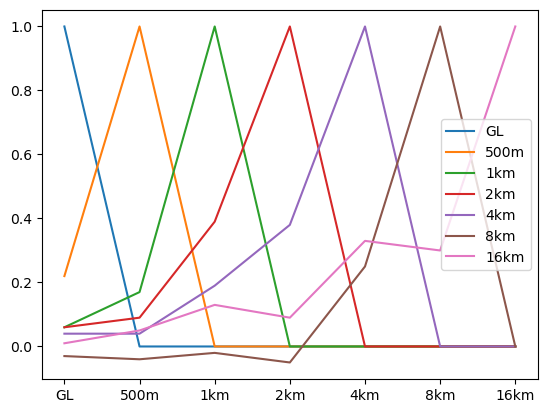

In [3]:
corr_matrix()

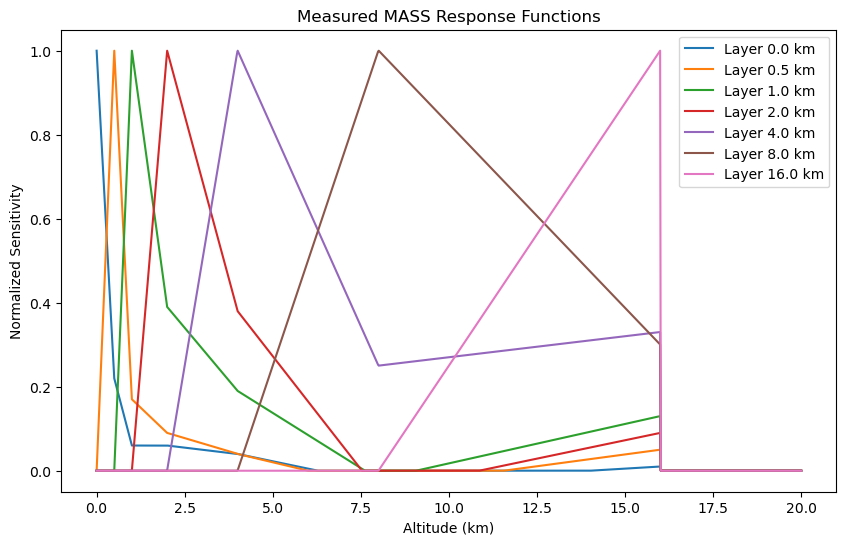

In [5]:
# Altitude grid (km)
alt = np.array([0, 0.5, 1, 2, 4, 8, 16])

# Your matrix (rows = reported layers)
M = np.array([
    [1.00, 0.22, 0.06, 0.06, 0.04, -0.03, 0.01],
    [0.00, 1.00, 0.17, 0.09, 0.04, -0.04, 0.05],
    [0.00, 0.00, 1.00, 0.39, 0.19, -0.02, 0.13],
    [0.00, 0.00, 0.00, 1.00, 0.38, -0.05, 0.09],
    [0.00, 0.00, 0.00, 0.00, 1.00, 0.25, 0.33],
    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.30],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
])

# Fine altitude grid
h_fine = np.linspace(0, 20, 1000)

plt.figure(figsize = (10,6))

for i, row in enumerate(M):
    f = interp1d(alt, row, kind='linear', bounds_error=False, fill_value=0)
    W = f(h_fine)
    W = np.maximum(W, 0)          # remove negative lobes
    W /= W.max()                  # normalize
    plt.plot(h_fine, W, label=f"Layer {alt[i]} km")

plt.xlabel("Altitude (km)")
plt.ylabel("Normalized Sensitivity")
plt.title("Measured MASS Response Functions")
plt.legend()
plt.show()